In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from sklearn.utils import resample
import os

In [6]:
file_path = "../data/final/DatasetfinaleMaugeri.xlsx"

df = pd.read_excel(file_path)

print("Shape originale:", df.shape)
print(df["Output:"].value_counts(dropna=False))

Shape originale: (195, 203)
Output:
PD    149
HS     46
Name: count, dtype: int64


In [7]:
asy_cols = [c for c in df.columns if "ASY" in c]

print("Numero colonne asimmetria:", len(asy_cols))

Numero colonne asimmetria: 120


In [9]:
cols_needed = ["Output:"] + asy_cols

df_analysis = df[cols_needed].dropna()

print("Shape dopo dropna sulle sole colonne utili:", df_analysis.shape)
print(df_analysis["Output:"].value_counts(dropna=False))

Shape dopo dropna sulle sole colonne utili: (194, 121)
Output:
PD    148
HS     46
Name: count, dtype: int64


In [16]:
pd_group = df_analysis[df_analysis["Output:"] == "PD"]
hs_group = df_analysis[df_analysis["Output:"] == "HS"]

print("PD:", len(pd_group))
print("HS:", len(hs_group))

PD: 148
HS: 46


In [17]:
def cliffs_delta(x, y):

    nx = len(x)
    ny = len(y)

    greater = 0
    lower = 0

    for xi in x:
        greater += np.sum(xi > y)
        lower += np.sum(xi < y)

    delta = (greater - lower) / (nx * ny)

    return delta

In [18]:
def cohens_d_bootstrap(x, y, n_boot=5000):

    diffs = []

    for _ in range(n_boot):

        xb = resample(x)
        yb = resample(y)

        pooled_sd = np.sqrt((np.var(xb) + np.var(yb)) / 2)

        if pooled_sd == 0:
            continue

        d = (np.mean(xb) - np.mean(yb)) / pooled_sd

        diffs.append(d)

    return np.mean(diffs)

In [19]:
results = []

for col in asy_cols:

    x = pd_group[col].values
    y = hs_group[col].values

    # Mann Whitney
    u, p = stats.mannwhitneyu(x, y, alternative="two-sided")

    # Cliff delta
    delta = cliffs_delta(x, y)

    # Cohen d
    d = cohens_d_bootstrap(x, y)

    results.append({
        "metric": col,
        "p_value": p,
        "cliffs_delta": delta,
        "cohens_d": d
    })

results_df = pd.DataFrame(results)

In [20]:
results_df["abs_delta"] = np.abs(results_df["cliffs_delta"])

results_df = results_df.sort_values(
    "abs_delta",
    ascending=False
)

results_df.head(20)

,metric,p_value,cliffs_delta,cohens_d,abs_delta
116,ASY12 Stance_time: totale,0.000007,0.439189,0.733802,0.439189
66,ASY7 Stance_time: totale,0.000015,0.422885,0.757589,0.422885
96,ASY10 Stance_time: totale,0.000015,-0.422738,-0.765624,0.422738
36,ASY4 Stance_time: totale,0.000015,0.422738,0.759870,0.422738
56,ASY6 Stance_time: totale,0.000015,0.422738,0.772973,0.422738
26,ASY3 Stance_time: totale,0.000015,0.422738,0.758461,0.422738
6,ASY1 Stance_time: totale,0.000015,0.422738,0.754391,0.422738
86,ASY9 Stance_time: totale,0.000015,0.422738,0.756960,0.422738
106,ASY11 Stance_time: totale,0.000015,0.422738,0.752952,0.422738
113,ASY12 Step_time: totale,0.000064,0.390717,0.690276,0.390717


In [21]:
results_df["formula"] = results_df["metric"].apply(lambda x: x.split()[0])

results_df["variable"] = results_df["metric"].apply(
    lambda x: " ".join(x.split()[1:-1])
)

In [22]:
formula_rank = results_df.groupby("formula")["abs_delta"].mean()

formula_rank = formula_rank.sort_values(ascending=False)

formula_rank

formula
ASY7     0.259621
ASY1     0.259592
ASY10    0.259592
ASY11    0.259592
ASY3     0.259592
ASY4     0.259592
ASY9     0.259592
ASY6     0.259445
ASY12    0.234195
ASY2     0.065702
ASY5     0.065702
ASY8     0.065702
Name: abs_delta, dtype: float64

In [23]:
variable_rank = results_df.groupby("variable")["abs_delta"].mean()

variable_rank = variable_rank.sort_values(ascending=False)

variable_rank

variable
Stance_time:         0.341277
Step_time:           0.303907
Supp_time_Single:    0.290014
Swing_time:          0.289708
Step_length:         0.189507
Stride_length:       0.172787
Stride_velocity:     0.151537
Supp_base:           0.145099
Supp_time_Double:    0.107582
Stride_time:         0.098512
Name: abs_delta, dtype: float64

In [24]:
os.makedirs("../results", exist_ok=True)

results_df.to_excel("../results/pd_vs_hs_metric_results.xlsx")

formula_rank.to_csv("../results/formula_ranking_PD_HS.csv")

variable_rank.to_csv("../results/variable_ranking_PD_HS.csv")

Top metriche discriminanti

Le prime posizioni sono:

metrica	Cliff's δ	Cohen's d
ASY12 Stance_time	0.439	0.73
ASY7 Stance_time	0.423	0.76
ASY10 Stance_time	0.423	0.76
ASY4 Stance_time	0.423	0.76
ASY6 Stance_time	0.423	0.77

Interpretazione:

le asimmetrie di STANCE TIME discriminano meglio PD vs HS

Effect size:

Cliff's δ ≈ 0.42
Cohen d ≈ 0.75

che è un effetto moderato-grande.

Questo è perfettamente plausibile perché nel Parkinson la fase di supporto è spesso asimmetrica tra i lati.

Ranking delle formule

Risultato molto interessante:

| formula | mean |δ| |
|---|---|
| ASY7 | 0.259 |
| ASY1 | 0.259 |
| ASY3 | 0.259 |
| ASY4 | 0.259 |
| ASY6 | 0.259 |
| ASY9 | 0.259 |
| ASY10 | 0.259 |
| ASY11 | 0.259 |

Praticamente identiche.

Interpretazione:

le formule sono matematicamente ridondanti

cioè:

formule diverse → stessa capacità discriminativa

Questo conferma tutto quello che avevi visto con PCA e correlazioni.

Formule peggiori

| formula | mean |δ| |
|---|---|
| ASY2 | 0.065 |
| ASY5 | 0.065 |
| ASY8 | 0.065 |

Queste sono le formule signed ratio.

Motivo:

mantengono il segno dell’asimmetria

quindi quando fai il confronto tra gruppi il segno si cancella.

Questo è un risultato metodologico molto importante.

Ranking delle variabili gait

Qui c'è la parte clinica più interessante.

| variabile | mean |δ| |
|---|---|
| Stance_time | 0.34 |
| Step_time | 0.30 |
| Supp_time_Single | 0.29 |
| Swing_time | 0.29 |

Interpretazione:

le variabili temporali sono le più sensibili nel PD

mentre quelle spaziali sono meno informative:

variabile	δ
Step_length	0.18
Stride_length	0.17

Questo è coerente con la fisiopatologia:

il Parkinson altera la temporal coordination del gait
più che le lunghezze di passo

Risultato metodologico chiave

Il dataset dimostra due cose molto forti:

1️⃣ ridondanza delle formule
molte metriche → stesso comportamento statistico
2️⃣ le variabili temporali sono le più informative
Stance_time
Step_time
Swing_time
5️⃣ Frase perfetta per Results

Puoi scrivere qualcosa del genere:

The largest group differences were observed for asymmetry in stance time (Cliff’s δ ≈ 0.42, Cohen’s d ≈ 0.75), followed by step time and single support time. Temporal gait variables consistently showed stronger discriminative power than spatial parameters such as step or stride length. Across formulas, most asymmetry indices yielded nearly identical effect sizes, confirming the strong mathematical redundancy among commonly used formulations. In contrast, ratio-based signed indices (ASY2, ASY5, ASY8) showed substantially lower discriminative ability.

Quale formula è migliore?
nessuna in modo sostanziale

le formule normalizzate o log-ratio sono equivalenti.

Quale variabile è più sensibile?
Stance_time
Step_time

che descrivono meglio l’alterazione del cammino nel PD.

In [25]:
heatmap_df = results_df.pivot_table(
    values="cliffs_delta",
    index="formula",
    columns="variable",
    aggfunc="mean"
)

heatmap_df

variable,Stance_time:,Step_length:,Step_time:,Stride_length:,Stride_time:,Stride_velocity:,Supp_base:,Supp_time_Double:,Supp_time_Single:,Swing_time:
formula,,,,,,,,,,
ASY1,0.422738,0.263807,0.381022,0.242949,0.121622,0.202996,-0.120447,0.122944,0.358696,0.358696
ASY10,-0.422738,-0.263807,-0.381022,-0.242949,-0.121622,-0.202996,0.120447,-0.122944,-0.358696,-0.358696
ASY11,0.422738,0.263807,0.381022,0.242949,0.121622,0.202996,-0.120447,0.122944,0.358696,0.358696
ASY12,0.439189,0.156580,0.390717,0.107521,0.139542,0.074618,-0.147180,0.207991,0.339307,0.339307
ASY2,-0.091363,-0.003231,0.069918,0.007051,-0.023208,0.039659,0.210928,0.033049,-0.089307,0.089307
ASY3,0.422738,0.263807,0.381022,0.242949,0.121622,0.202996,-0.120447,0.122944,0.358696,0.358696
ASY4,0.422738,0.263807,0.381022,0.242949,0.121622,0.202996,-0.120447,0.122944,0.358696,0.358696
ASY5,-0.091363,-0.003231,0.069918,0.007051,-0.023208,0.039659,0.210928,0.033049,-0.089307,0.089307
ASY6,0.422738,0.261163,0.379260,0.244125,0.121622,0.203878,-0.118096,0.123237,0.361927,0.358402


In [26]:
heatmap_df = heatmap_df[variable_rank.index]

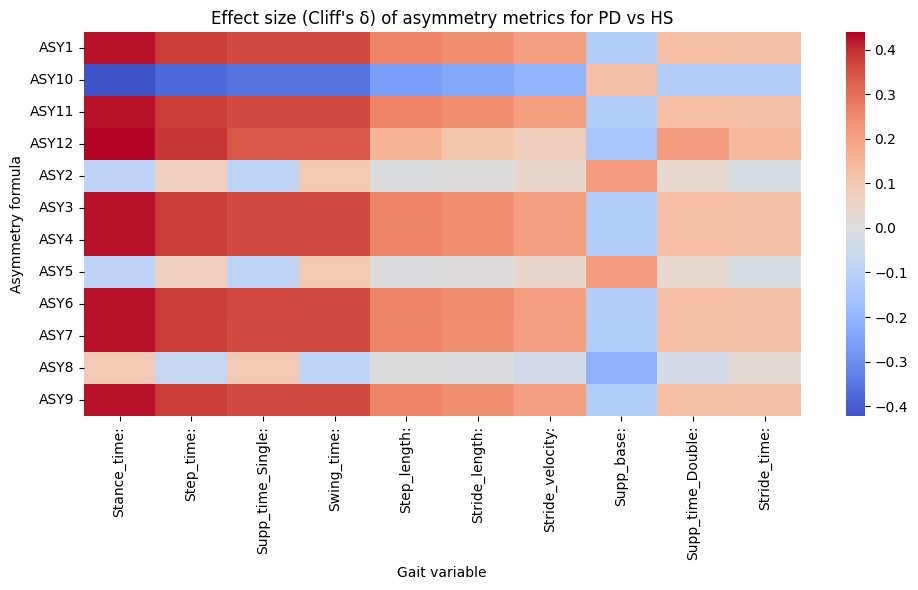

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_df,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Effect size (Cliff's δ) of asymmetry metrics for PD vs HS")
plt.xlabel("Gait variable")
plt.ylabel("Asymmetry formula")

plt.tight_layout()

plt.show()

In [28]:
plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_df,
    cmap="coolwarm",
    center=0
)

plt.title("Effect size (Cliff's δ) of asymmetry metrics for PD vs HS")

plt.tight_layout()

plt.savefig("../results/pd_vs_hs_effectsize_heatmap.png", dpi=300)

plt.close()

1️⃣ Pattern principale: variabili temporali dominano

Le colonne con effetto maggiore sono:

Variabile	Cliff’s δ (circa)
Stance_time	~0.42–0.44
Step_time	~0.38
Supp_time_single	~0.36
Swing_time	~0.36

Interpretazione biomeccanica:

le asimmetrie temporali discriminano PD vs HS molto più delle variabili spaziali

Questo è coerente con la fisiopatologia del Parkinson:

alterazione del timing motorio

controllo bilaterale della fase di supporto

coordinazione interlimbica

Le variabili spaziali (step length, stride length) sono invece molto meno sensibili.

2️⃣ Pattern sulle formule

Le righe della heatmap sono quasi identiche per:

ASY1
ASY3
ASY4
ASY6
ASY7
ASY9
ASY11

cioè:

la scelta della formula non cambia quasi nulla

Questo conferma ridondanza matematica delle metriche.

3️⃣ Le formule “signed” funzionano male

Le formule:

ASY2
ASY5
ASY8

mostrano effect size molto più piccoli.

Motivo matematico:

preservano il segno dell’asimmetria

Quando confronti gruppi:

PD_left > PD_right
PD_right > PD_left

il segno si annulla.

Per questo nel confronto tra gruppi funzionano peggio.

4️⃣ Il caso di ASY10

ASY10 appare con segno opposto:

min(L,R) / max(L,R)

Quindi:

valori piccoli → più asimmetria

Questo spiega il colore invertito nella heatmap.

Statisticamente è equivalente alle altre formule, solo invertito.

5️⃣ Il vero driver clinico

Il driver principale della discriminazione è chiaramente:

stance time asymmetry

δ ≈ 0.42
d ≈ 0.75

Quindi:

PD → stance time più asimmetrico

che è coerente con:

instabilità posturale

controllo unilaterale del supporto

6️⃣ Cosa dimostra questa figura

Questa heatmap dimostra tre cose contemporaneamente:

1️⃣ Ridondanza delle formule
molte formule → stesso comportamento
2️⃣ Dominanza delle variabili temporali
temporal > spatial gait parameters
3️⃣ Ruolo centrale della stance phase
stance_time asymmetry = miglior discriminante
7️⃣ Frase per un paper

Potresti scrivere qualcosa del genere:

The heatmap of effect sizes across asymmetry formulations and gait variables revealed highly consistent patterns across most metrics. Temporal parameters, particularly stance time asymmetry, showed the strongest discrimination between PD and HS (Cliff’s δ ≈ 0.42). Spatial variables such as step and stride length displayed substantially smaller effect sizes. Across formulas, most indices produced nearly identical effect sizes, confirming the strong mathematical redundancy among commonly used asymmetry metrics. Signed ratio-based formulations showed markedly reduced discrimination.

8️⃣ Implicazione metodologica

Questo porta a una conclusione molto importante:

la scelta della variabile è più importante
della scelta della formula